# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint



### Not for Grading

## Setup Steps

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2418580" #@param {type:"string"}


In [ ]:
#@title Please enter your password (normally your phone number) to continue: { run: "auto", display-mode: "form" }
password = "9898989865" #@param {type:"string"}


In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython

ipython = get_ipython()

notebook= "Demo_DatasetsAPI" #name of the notebook
Answer = "Ungraded"
def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Purchase_Dataset.csv")
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():

    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword()}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getComplexity() and getAdditional() and getConcepts() and getComments():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "id" : Id, "file_hash" : file_hash,
              "feedback_experiments_input" : Comments, "notebook" : notebook}

      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions")
        # print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
      return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None
def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None

def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()

else:
  print ("Please complete Id and Password cells before running setup")


Setup completed successfully


# Datasets

There are three distinct kinds of dataset interfaces for different types of datasets. The simplest one is the interface for sample images, which is described below in the Sample images section.

The dataset generation functions and the svmlight loader share a simplistic interface, returning a tuple `(X, y)` consisting of a `n_samples * n_features` numpy array `X` and an array of length n_samples containing the targets `y`.

The toy datasets as well as the ‘real world’ datasets and the datasets fetched from mldata.org have more sophisticated structure. These functions return a dictionary-like object holding at least two items: an array of shape `n_samples * n_features` with key `data` (except for 20newsgroups) and a numpy array of length `n_samples`, containing the target values, with key `target`.

The datasets also contain a description in `DESCR` and some contain `feature_names` and `target_names`. See the dataset descriptions below for details.

In [ ]:
%pylab inline

import sklearn.datasets as datasets

Populating the interactive namespace from numpy and matplotlib


## Sample Images

The scikit also embed a couple of sample JPEG images published under Creative Commons license by their authors. Those image can be useful to test algorithms and pipeline on 2D data.

In [ ]:
# datasets.load_sample_images()
china = datasets.load_sample_image('china.jpg')

flower = datasets.load_sample_image('flower.jpg')

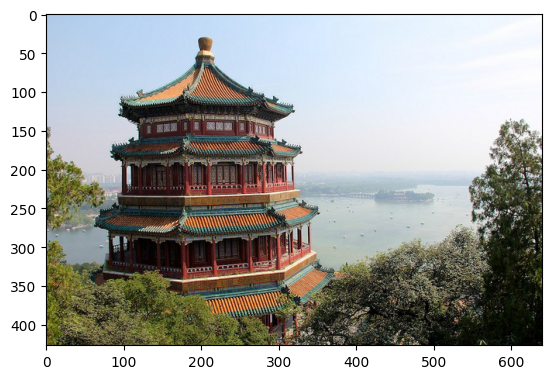

In [ ]:
plt.imshow(china)

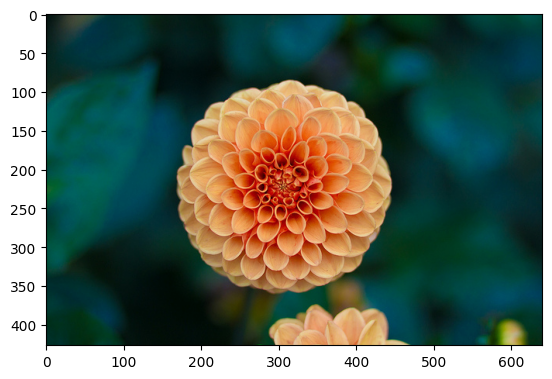

In [ ]:
plt.imshow(flower)

In [ ]:
flower.shape

(427, 640, 3)

## Sample Generators

In addition, scikit-learn includes various random sample generators that can be used to build artificial datasets of controlled size and complexity.

All of the generators are prefixed with the word `make`

In [ ]:
datasets.make_blobs?

In [ ]:
X, y = datasets.make_blobs()

In [ ]:
X.shape, y.shape

((100, 2), (100,))

## Toy and Fetched Datasets

Scikit-learn comes with a few small standard datasets that do not require to download any file from some external website.

These datasets are useful to quickly illustrate the behavior of the various algorithms implemented in the scikit. They are however often too small to be representative of real world machine learning tasks.

These datasets are prefixed with the `load` command.

In [ ]:
from sklearn.datasets import fetch_openml

# Fetch the Boston housing dataset
boston = fetch_openml(name='boston', version=1)

In [ ]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
boston.data.shape, boston.target.shape

((506, 13), (506,))

In [ ]:
boston.feature_names

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [ ]:
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

#### Fetched datasets

These are all somewhat unique with their own functions to fetch and load them. I'll go through a single one below. They are all prefixed with the word `fetch`

In [ ]:
faces = datasets.fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
faces.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [ ]:
faces.images.shape, faces.data.shape, faces.target.shape

((400, 64, 64), (400, 4096), (400,))

## Please answer the questions below to complete the experiment:

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good and Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [ ]:
#@title If it was very easy, what more you would have liked to have been added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "d\"sad\"smore you\" would have liked to have been added? If it was very \"difficult, what would you have liked to have been removed? [ ] Additional:" #@param {type:"string"}

In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "No" #@param ["","Yes", "No"]

In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Didn't use" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Run this cell to submit your notebook  { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id =return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 8391
Date of submission:  13 May 2025
Time of submission:  01:33:47
View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions
